In [8]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Unzip all RAVDESS video files into Colab
import os

zip_dir = "/content/drive/MyDrive/RAVDESS"
output_dir = "/content/RAVDESS"

os.makedirs(output_dir, exist_ok=True)

for zip_file in os.listdir(zip_dir):
    if zip_file.endswith(".zip"):
        zip_path = os.path.join(zip_dir, zip_file)
        !unzip -q "{zip_path}" -d "{output_dir}"

print("✅ All RAVDESS video files extracted!")

# 3. Extract frames from videos (using OpenCV)
import cv2

frame_dir = "/content/RAVDESS_frames"
os.makedirs(frame_dir, exist_ok=True)

for root, dirs, files in os.walk(output_dir):
    for file in files:
        if file.endswith(".mp4"):
            video_path = os.path.join(root, file)
            cap = cv2.VideoCapture(video_path)
            count = 0
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                # Save 1 frame per second
                if int(cap.get(cv2.CAP_PROP_POS_FRAMES)) % int(cap.get(cv2.CAP_PROP_FPS)) == 0:
                    frame_name = f"{os.path.splitext(file)[0]}_{count}.jpg"
                    cv2.imwrite(os.path.join(frame_dir, frame_name), frame)
                    count += 1
            cap.release()

print("✅ Frames extracted from RAVDESS videos!")




Mounted at /content/drive
✅ All RAVDESS video files extracted!
✅ Frames extracted from RAVDESS videos!


In [3]:
# 4. Training setup with PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from PIL import Image

class RAVDESSFrames(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = [os.path.join(root_dir, f) for f in os.listdir(root_dir)]
        # Example: binary labels (happy vs not happy)
        self.labels = [0 if "happy" not in f else 1 for f in self.image_files]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

train_dataset = RAVDESSFrames(frame_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 5. Load ResNet18
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2)  # Binary classification
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 6. Training loop
epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}, Accuracy: {100*correct/total:.2f}%")

    # Save checkpoint to Drive
    torch.save(model.state_dict(), f"/content/drive/MyDrive/RAVDESS_checkpoint_epoch{epoch+1}.pth")

print("🎉 Training finished!")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 87.7MB/s]


Epoch 1/10, Loss: 0.0129, Accuracy: 99.85%
Epoch 2/10, Loss: 0.0004, Accuracy: 100.00%
Epoch 3/10, Loss: 0.0002, Accuracy: 100.00%
Epoch 4/10, Loss: 0.0001, Accuracy: 100.00%
Epoch 5/10, Loss: 0.0001, Accuracy: 100.00%
Epoch 6/10, Loss: 0.0001, Accuracy: 100.00%
Epoch 7/10, Loss: 0.0001, Accuracy: 100.00%
Epoch 8/10, Loss: 0.0000, Accuracy: 100.00%
Epoch 9/10, Loss: 0.0000, Accuracy: 100.00%
Epoch 10/10, Loss: 0.0000, Accuracy: 100.00%
🎉 Training finished!


In [5]:
import os
import cv2
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from PIL import Image

# Dataset class: sample one frame per video
class CREMAVideoDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.video_files = [os.path.join(root_dir, f)
                            for f in os.listdir(root_dir) if f.endswith(".flv")]

    def __len__(self):
        return len(self.video_files)

    def __getitem__(self, idx):
        video_path = self.video_files[idx]
        label = 1 if "HAP" in video_path else 0  # happy vs not happy

        cap = cv2.VideoCapture(video_path)
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        target_frame = frame_count // 2  # middle frame
        cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
        ret, frame = cap.read()
        cap.release()

        # Convert to PIL Image
        image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        if self.transform:
            image = self.transform(image)
        return image, label

# Transform (same as training)
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

# Validation dataset and loader
crema_video_dir = "/content/drive/MyDrive/VideoFlash"
val_dataset = CREMAVideoDataset(crema_video_dir, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Load trained model checkpoint
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load("/content/drive/MyDrive/RAVDESS_checkpoint_epoch10.pth"))
model = model.to(device)
model.eval()

criterion = nn.CrossEntropyLoss()

# Validation loop
val_loss, val_correct, val_total = 0, 0, 0
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        val_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        val_total += labels.size(0)
        val_correct += (predicted == labels).sum().item()

print(f"Validation Loss: {val_loss/len(val_loader):.4f}, "
      f"Validation Accuracy: {100*val_correct/val_total:.2f}%")


Validation Loss: 1.0370, Validation Accuracy: 82.93%


In [ ]:
import os
import cv2
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from PIL import Image

# Dataset class: sample one frame per video
class AFEWVideoDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.video_files = [os.path.join(root_dir, f)
                            for f in os.listdir(root_dir) if f.endswith(".avi") or f.endswith(".mp4")]

    def __len__(self):
        return len(self.video_files)

    def __getitem__(self, idx):
        video_path = self.video_files[idx]

        # Example: parse label from filename (depends on AFEW naming convention)
        # Adjust this line based on how your AFEW files are named
        if "Happy" in video_path:
            label = 1
        else:
            label = 0  # not happy

        cap = cv2.VideoCapture(video_path)
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        target_frame = frame_count // 2  # middle frame
        cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
        ret, frame = cap.read()
        cap.release()

        image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        if self.transform:
            image = self.transform(image)
        return image, label

# Transform (same as training)
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

# Test dataset and loader
afew_video_dir = "/content/drive/MyDrive/AFEW/VideoClips"
test_dataset = AFEWVideoDataset(afew_video_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Load trained model checkpoint
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load("/content/drive/MyDrive/RAVDESS_checkpoint_epoch10.pth"))
model = model.to(device)
model.eval()

criterion = nn.CrossEntropyLoss()

# Test loop
test_loss, test_correct, test_total = 0, 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

print(f"Test Loss: {test_loss/len(test_loader):.4f}, "
      f"Test Accuracy: {100*test_correct/test_total:.2f}%")


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

Validation Loss: 1.0370
Accuracy: 82.93%
Precision: 0.0000
Recall: 0.0000
F1-score: 0.0000

Classification Report:
               precision    recall  f1-score   support

           0       0.83      1.00      0.91      5765
           1       0.00      0.00      0.00      1187

    accuracy                           0.83      6952
   macro avg       0.41      0.50      0.45      6952
weighted avg       0.69      0.83      0.75      6952



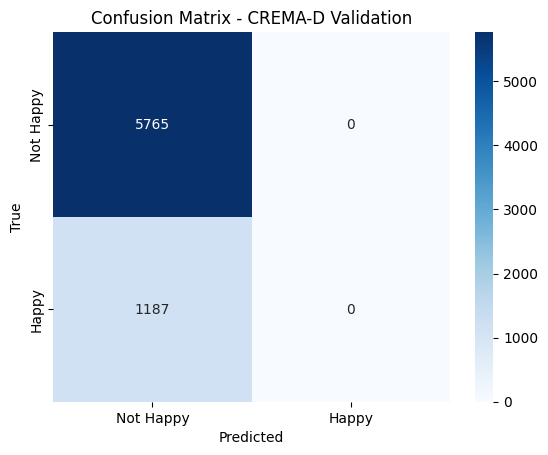

In [6]:
import os
import cv2
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Dataset class: sample one frame per video
class CREMAVideoDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.video_files = [os.path.join(root_dir, f)
                            for f in os.listdir(root_dir) if f.endswith(".flv")]

    def __len__(self):
        return len(self.video_files)

    def __getitem__(self, idx):
        video_path = self.video_files[idx]
        label = 1 if "HAP" in video_path else 0  # happy vs not happy

        cap = cv2.VideoCapture(video_path)
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        target_frame = frame_count // 2  # middle frame
        cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
        ret, frame = cap.read()
        cap.release()

        image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        if self.transform:
            image = self.transform(image)
        return image, label

# Transform (same as training)
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

# Validation dataset and loader
crema_video_dir = "/content/drive/MyDrive/VideoFlash"
val_dataset = CREMAVideoDataset(crema_video_dir, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Load trained model checkpoint
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights=None)  # updated API
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load("/content/drive/MyDrive/RAVDESS_checkpoint_epoch10.pth"))
model = model.to(device)
model.eval()

criterion = nn.CrossEntropyLoss()

# Validation loop with metrics
val_loss = 0
all_labels, all_preds = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        val_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

# Compute metrics
val_loss /= len(val_loader)
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='binary')
rec = recall_score(all_labels, all_preds, average='binary')
f1 = f1_score(all_labels, all_preds, average='binary')
cm = confusion_matrix(all_labels, all_preds)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Accuracy: {acc*100:.2f}%")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")
print("\nClassification Report:\n", classification_report(all_labels, all_preds))

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Happy","Happy"], yticklabels=["Not Happy","Happy"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - CREMA-D Validation")
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

Validation Loss: 1.0370
Accuracy: 82.93%
Precision: 0.0000
Recall: 0.0000
F1-score: 0.0000
MCC: 0.0000
Cohen's Kappa: 0.0000
ROC-AUC: 0.5474

Classification Report:
               precision    recall  f1-score   support

           0       0.83      1.00      0.91      5765
           1       0.00      0.00      0.00      1187

    accuracy                           0.83      6952
   macro avg       0.41      0.50      0.45      6952
weighted avg       0.69      0.83      0.75      6952



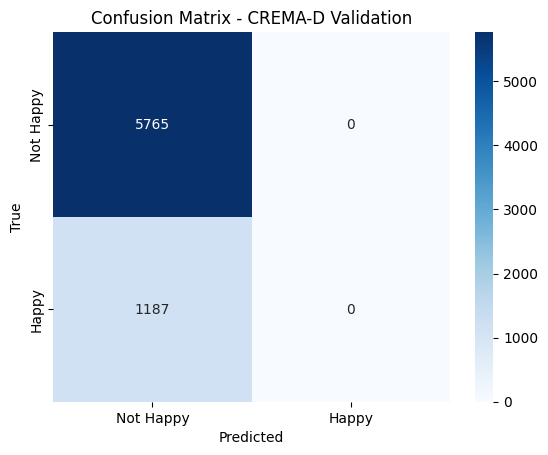

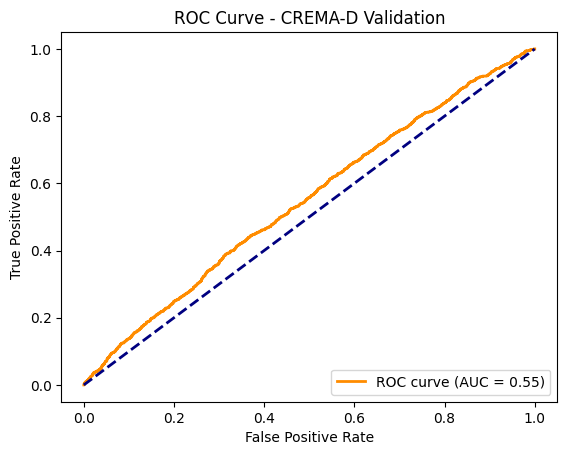

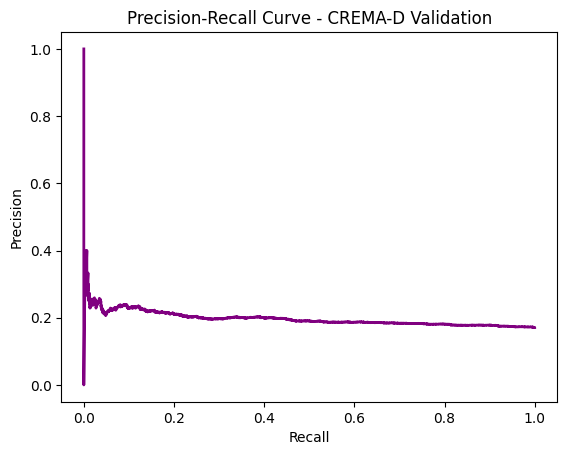

In [7]:
import os
import cv2
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, auc,
                             precision_recall_curve, matthews_corrcoef, cohen_kappa_score)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Dataset class: sample one frame per video
class CREMAVideoDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.video_files = [os.path.join(root_dir, f)
                            for f in os.listdir(root_dir) if f.endswith(".flv")]

    def __len__(self):
        return len(self.video_files)

    def __getitem__(self, idx):
        video_path = self.video_files[idx]
        label = 1 if "HAP" in video_path else 0  # happy vs not happy

        cap = cv2.VideoCapture(video_path)
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        target_frame = frame_count // 2
        cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
        ret, frame = cap.read()
        cap.release()

        image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        if self.transform:
            image = self.transform(image)
        return image, label

# Transform (same as training)
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

# Validation dataset and loader
crema_video_dir = "/content/drive/MyDrive/VideoFlash"
val_dataset = CREMAVideoDataset(crema_video_dir, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Load trained model checkpoint
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights=None)  # updated API
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load("/content/drive/MyDrive/RAVDESS_checkpoint_epoch10.pth"))
model = model.to(device)
model.eval()

criterion = nn.CrossEntropyLoss()

# Validation loop
val_loss = 0
all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        val_loss += loss.item()
        probs = torch.softmax(outputs, dim=1)[:,1]  # probability of "happy"
        _, predicted = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Metrics
val_loss /= len(val_loader)
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='binary')
rec = recall_score(all_labels, all_preds, average='binary')
f1 = f1_score(all_labels, all_preds, average='binary')
cm = confusion_matrix(all_labels, all_preds)
mcc = matthews_corrcoef(all_labels, all_preds)
kappa = cohen_kappa_score(all_labels, all_preds)

# ROC-AUC
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

# Precision-Recall curve
prec_curve, rec_curve, _ = precision_recall_curve(all_labels, all_probs)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Accuracy: {acc*100:.2f}%")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print("\nClassification Report:\n", classification_report(all_labels, all_preds))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Happy","Happy"], yticklabels=["Not Happy","Happy"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - CREMA-D Validation")
plt.show()

# ROC Curve
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CREMA-D Validation")
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve
plt.plot(rec_curve, prec_curve, color='purple', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - CREMA-D Validation")
plt.show()


Training with data augnmentation, cross validation

In [9]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import models, transforms

from sklearn.model_selection import KFold

from PIL import Image

# ============================================================
# Dataset
# ============================================================

class RAVDESSFrames(Dataset):

    def __init__(self, root_dir, transform=None):

        self.root_dir = root_dir
        self.transform = transform

        self.image_files = [
            os.path.join(root_dir, f)
            for f in os.listdir(root_dir)
        ]

        # Binary labels
        # happy = 1
        # not happy = 0

        self.labels = [
            0 if "happy" not in f.lower() else 1
            for f in self.image_files
        ]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):

        img_path = self.image_files[idx]

        image = Image.open(img_path).convert("RGB")

        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# ============================================================
# Augmentation
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# ============================================================
# Dataset Initialization
# Uses your existing frame_dir variable
# ============================================================

full_dataset = RAVDESSFrames(
    frame_dir,
    transform=train_transform
)

print(f"✅ Total frames: {len(full_dataset)}")

# ============================================================
# Device
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"✅ Using device: {device}")

# ============================================================
# Cross Validation
# ============================================================

k_folds = 3

kf = KFold(
    n_splits=k_folds,
    shuffle=True,
    random_state=42
)

# ============================================================
# Training Config
# ============================================================

max_epochs = 3

loss_threshold = 0.0005

patience = 2

# ============================================================
# Cross Validation Loop
# ============================================================

for fold, (train_ids, val_ids) in enumerate(kf.split(full_dataset)):

    print("\n================================")
    print(f"🚀 Fold {fold+1}/{k_folds}")
    print("================================")

    # ========================================================
    # Split datasets
    # ========================================================

    train_subset = Subset(full_dataset, train_ids)

    val_subset = Subset(full_dataset, val_ids)

    train_loader = DataLoader(
        train_subset,
        batch_size=32,
        shuffle=True
    )

    val_loader = DataLoader(
        val_subset,
        batch_size=32,
        shuffle=False
    )

    # ========================================================
    # Model
    # ========================================================

    model = models.resnet18(pretrained=True)

    model.fc = nn.Linear(
        model.fc.in_features,
        2
    )

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-4
    )

    # ========================================================
    # Early stopping variables
    # ========================================================

    previous_loss = float("inf")

    flat_counter = 0

    # ========================================================
    # Epoch loop
    # ========================================================

    for epoch in range(max_epochs):

        # ================= TRAIN =================

        model.train()

        running_loss = 0

        correct = 0

        total = 0

        for images, labels in train_loader:

            images = images.to(device)

            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

        train_loss = running_loss / len(train_loader)

        train_acc = 100 * correct / total

        # ================= VALIDATION =================

        model.eval()

        val_loss = 0

        val_correct = 0

        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)

                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                val_total += labels.size(0)

                val_correct += (
                    predicted == labels
                ).sum().item()

        val_loss /= len(val_loader)

        val_acc = 100 * val_correct / val_total

        # ====================================================
        # Metrics
        # ====================================================

        print(
            f"Epoch [{epoch+1}/{max_epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.2f}%"
        )

        # ====================================================
        # Flat loss detector
        # ====================================================

        loss_change = abs(previous_loss - val_loss)

        if loss_change < loss_threshold:

            flat_counter += 1

            print(
                f"⚠️ Validation loss flat "
                f"({flat_counter}/{patience})"
            )

        else:

            flat_counter = 0

        # ====================================================
        # Early stopping
        # ====================================================

        if flat_counter >= patience:

            print("🛑 Early stopping triggered")

            break

        previous_loss = val_loss

    # ========================================================
    # Save model
    # ========================================================

    save_path = (
        f"/content/drive/MyDrive/"
        f"RAVDESS_fold_{fold+1}.pth"
    )

    torch.save(
        model.state_dict(),
        save_path
    )

    print(f"✅ Saved: {save_path}")

print("\n🎉 Training completed!")

✅ Total frames: 9406
✅ Using device: cpu

🚀 Fold 1/3


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 99.6MB/s]


Epoch [1/3] | Train Loss: 0.0392 | Train Acc: 98.52% | Val Loss: 0.0018 | Val Acc: 100.00%
Epoch [2/3] | Train Loss: 0.0012 | Train Acc: 100.00% | Val Loss: 0.0008 | Val Acc: 100.00%
Epoch [3/3] | Train Loss: 0.0007 | Train Acc: 100.00% | Val Loss: 0.0005 | Val Acc: 100.00%
⚠️ Validation loss flat (1/2)
✅ Saved: /content/drive/MyDrive/RAVDESS_fold_1.pth

🚀 Fold 2/3
Epoch [1/3] | Train Loss: 0.0513 | Train Acc: 97.66% | Val Loss: 0.0024 | Val Acc: 100.00%
Epoch [2/3] | Train Loss: 0.0015 | Train Acc: 100.00% | Val Loss: 0.0010 | Val Acc: 100.00%
Epoch [3/3] | Train Loss: 0.0008 | Train Acc: 100.00% | Val Loss: 0.0006 | Val Acc: 100.00%
⚠️ Validation loss flat (1/2)
✅ Saved: /content/drive/MyDrive/RAVDESS_fold_2.pth

🚀 Fold 3/3
Epoch [1/3] | Train Loss: 0.0273 | Train Acc: 99.65% | Val Loss: 0.0016 | Val Acc: 100.00%
Epoch [2/3] | Train Loss: 0.0010 | Train Acc: 100.00% | Val Loss: 0.0006 | Val Acc: 100.00%
Epoch [3/3] | Train Loss: 0.0005 | Train Acc: 100.00% | Val Loss: 0.0004 | Val Ac

VALIDATION WITH CREMA-D

In [11]:
import os
import cv2
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ============================================================
# CREMA-D VIDEO VALIDATION DATASET
# ============================================================

class CREMAVideoDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.root_dir = root_dir
        self.transform = transform

        self.video_files = [

            os.path.join(root_dir, f)

            for f in os.listdir(root_dir)

            if f.endswith(".flv")
        ]

    def __len__(self):

        return len(self.video_files)

    def __getitem__(self, idx):

        video_path = self.video_files[idx]

        filename = os.path.basename(video_path)

        # ====================================================
        # CREMA-D Labels
        #
        # HAP = happy
        #
        # Binary classification:
        # happy = 1
        # all others = 0
        # ====================================================

        label = 1 if "_HAP_" in filename else 0

        # ====================================================
        # Read middle frame
        # ====================================================

        cap = cv2.VideoCapture(video_path)

        frame_count = int(
            cap.get(cv2.CAP_PROP_FRAME_COUNT)
        )

        target_frame = frame_count // 2

        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            target_frame
        )

        ret, frame = cap.read()

        cap.release()

        # fallback if frame fails
        if not ret:

            image = Image.new(
                "RGB",
                (224,224)
            )

        else:

            image = Image.fromarray(
                cv2.cvtColor(
                    frame,
                    cv2.COLOR_BGR2RGB
                )
            )

        if self.transform:

            image = self.transform(image)

        return image, label

# ============================================================
# TRANSFORMS
# SAME AS TRAINING VALIDATION TRANSFORM
# ============================================================

transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# ============================================================
# CREMA-D VALIDATION DATASET
# ============================================================

crema_video_dir = "/content/drive/MyDrive/VideoFlash"

val_dataset = CREMAVideoDataset(
    crema_video_dir,
    transform=transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print(f"✅ Total validation videos: {len(val_dataset)}")

# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"✅ Using device: {device}")

# ============================================================
# LOAD TRAINED MODEL
#
# Use one fold model from cross-validation
# ============================================================

model = models.resnet18(pretrained=False)

model.fc = nn.Linear(
    model.fc.in_features,
    2
)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/RAVDESS_fold_1.pth",
        map_location=device
    )
)

model = model.to(device)

model.eval()

print("✅ Model loaded successfully")

# ============================================================
# LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss()

# ============================================================
# VALIDATION LOOP
# ============================================================

val_loss = 0

all_labels = []

all_predictions = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        val_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predicted.cpu().numpy()
        )

# ============================================================
# METRICS
# ============================================================

avg_loss = val_loss / len(val_loader)

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    zero_division=0
)

cm = confusion_matrix(
    all_labels,
    all_predictions
)

# ============================================================
# RESULTS
# ============================================================

print("\n==============================")
print("📊 CREMA-D VALIDATION RESULTS")
print("==============================")

print(f"Validation Loss: {avg_loss:.4f}")

print(f"Accuracy:  {accuracy*100:.2f}%")

print(f"Precision: {precision:.4f}")

print(f"Recall:    {recall:.4f}")

print(f"F1-Score:  {f1:.4f}")

print("\nConfusion Matrix:")

print(cm)

✅ Total validation videos: 7442
✅ Using device: cpu


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Model loaded successfully

📊 CREMA-D VALIDATION RESULTS
Validation Loss: 0.9794
Accuracy:  82.92%
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000

Confusion Matrix:
[[6171    0]
 [1271    0]]


VALIDATE WITH MORE METRICS

✅ Total validation videos: 7442
✅ Using device: cpu


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Model loaded successfully

📊 CREMA-D VALIDATION RESULTS
Validation Loss: 0.9794
Accuracy:  82.92%
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000

Classification Report:

              precision    recall  f1-score   support

   Not Happy       0.83      1.00      0.91      6171
       Happy       0.00      0.00      0.00      1271

    accuracy                           0.83      7442
   macro avg       0.41      0.50      0.45      7442
weighted avg       0.69      0.83      0.75      7442



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


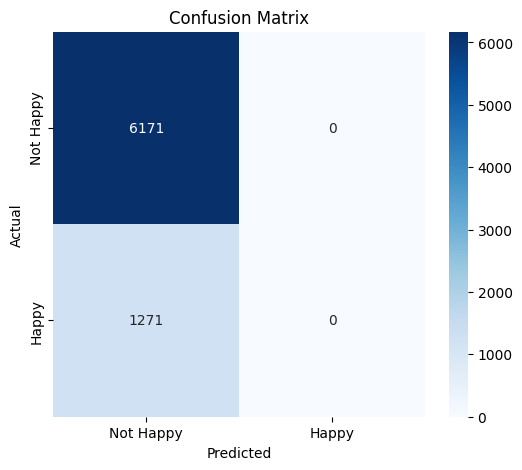

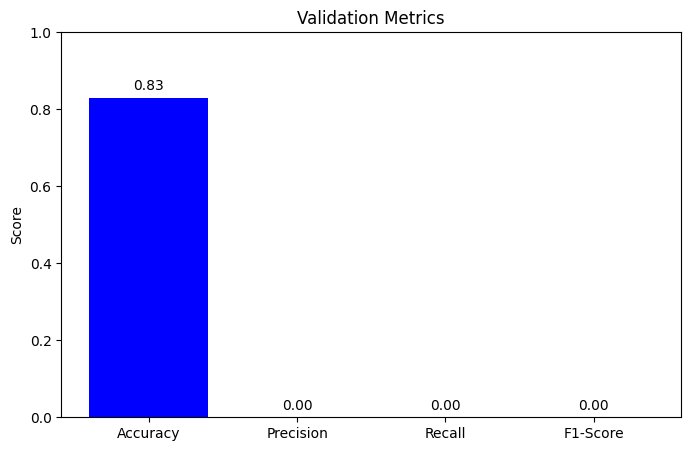

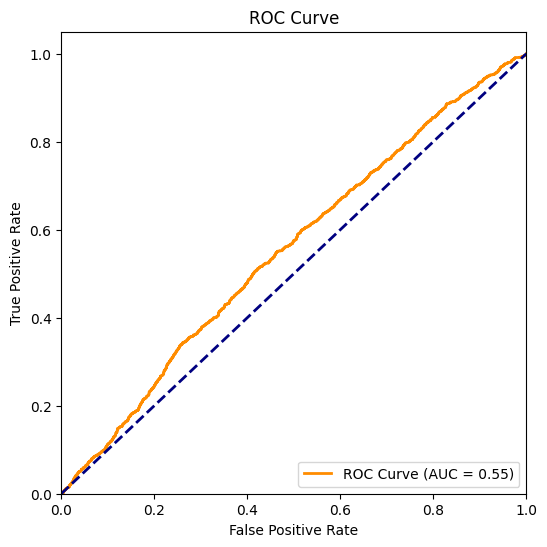

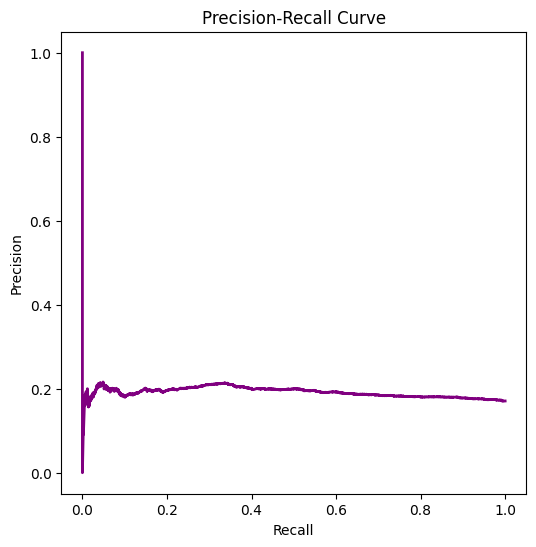

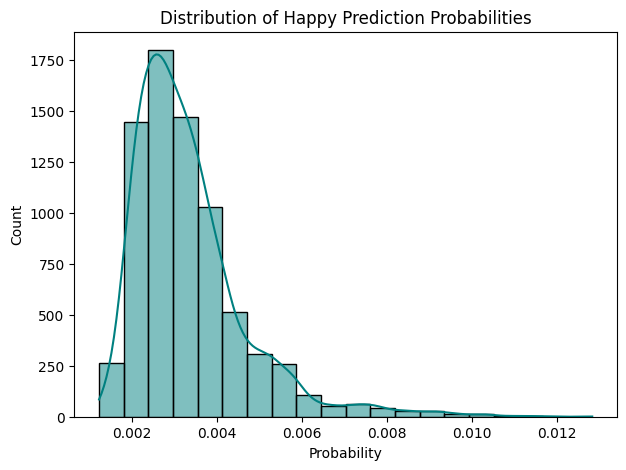


✅ Evaluation completed successfully!


In [12]:
import os
import cv2
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

from PIL import Image

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)

# ============================================================
# CREMA-D VIDEO VALIDATION DATASET
# ============================================================

class CREMAVideoDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.root_dir = root_dir
        self.transform = transform

        self.video_files = [

            os.path.join(root_dir, f)

            for f in os.listdir(root_dir)

            if f.endswith(".flv")
        ]

    def __len__(self):

        return len(self.video_files)

    def __getitem__(self, idx):

        video_path = self.video_files[idx]

        filename = os.path.basename(video_path)

        # ====================================================
        # CREMA-D Labels
        #
        # HAP = happy
        # ====================================================

        label = 1 if "_HAP_" in filename else 0

        # ====================================================
        # Read middle frame
        # ====================================================

        cap = cv2.VideoCapture(video_path)

        frame_count = int(
            cap.get(cv2.CAP_PROP_FRAME_COUNT)
        )

        target_frame = frame_count // 2

        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            target_frame
        )

        ret, frame = cap.read()

        cap.release()

        if not ret:

            image = Image.new(
                "RGB",
                (224,224)
            )

        else:

            image = Image.fromarray(
                cv2.cvtColor(
                    frame,
                    cv2.COLOR_BGR2RGB
                )
            )

        if self.transform:

            image = self.transform(image)

        return image, label

# ============================================================
# TRANSFORMS
# ============================================================

transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# ============================================================
# DATASET
# ============================================================

crema_video_dir = "/content/drive/MyDrive/VideoFlash"

val_dataset = CREMAVideoDataset(
    crema_video_dir,
    transform=transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print(f"✅ Total validation videos: {len(val_dataset)}")

# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"✅ Using device: {device}")

# ============================================================
# MODEL
# ============================================================

model = models.resnet18(pretrained=False)

model.fc = nn.Linear(
    model.fc.in_features,
    2
)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/RAVDESS_fold_1.pth",
        map_location=device
    )
)

model = model.to(device)

model.eval()

print("✅ Model loaded successfully")

# ============================================================
# LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss()

# ============================================================
# VALIDATION LOOP
# ============================================================

val_loss = 0

all_labels = []

all_predictions = []

all_probabilities = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        val_loss += loss.item()

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        happy_probs = probabilities[:,1]

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predicted.cpu().numpy()
        )

        all_probabilities.extend(
            happy_probs.cpu().numpy()
        )

# ============================================================
# METRICS
# ============================================================

avg_loss = val_loss / len(val_loader)

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    zero_division=0
)

cm = confusion_matrix(
    all_labels,
    all_predictions
)

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n==============================")
print("📊 CREMA-D VALIDATION RESULTS")
print("==============================")

print(f"Validation Loss: {avg_loss:.4f}")

print(f"Accuracy:  {accuracy*100:.2f}%")

print(f"Precision: {precision:.4f}")

print(f"Recall:    {recall:.4f}")

print(f"F1-Score:  {f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=[
            "Not Happy",
            "Happy"
        ]
    )
)

# ============================================================
# CONFUSION MATRIX PLOT
# ============================================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Happy","Happy"],
    yticklabels=["Not Happy","Happy"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# ============================================================
# METRICS BAR CHART
# ============================================================

metrics_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

metrics_values = [
    accuracy,
    precision,
    recall,
    f1
]

plt.figure(figsize=(8,5))

bars = plt.bar(
    metrics_names,
    metrics_values,
    color=[
        "blue",
        "green",
        "orange",
        "red"
    ]
)

plt.ylim(0,1)

plt.title("Validation Metrics")

plt.ylabel("Score")

# show values on bars
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.2f}",
        ha='center'
    )

plt.show()

# ============================================================
# ROC CURVE
# ============================================================

fpr, tpr, thresholds = roc_curve(
    all_labels,
    all_probabilities
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"ROC Curve (AUC = {roc_auc:.2f})"
)

plt.plot(
    [0,1],
    [0,1],
    color="navy",
    lw=2,
    linestyle="--"
)

plt.xlim([0.0,1.0])

plt.ylim([0.0,1.05])

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.show()

# ============================================================
# PRECISION-RECALL CURVE
# ============================================================

precision_curve, recall_curve, _ = precision_recall_curve(
    all_labels,
    all_probabilities
)

plt.figure(figsize=(6,6))

plt.plot(
    recall_curve,
    precision_curve,
    color="purple",
    lw=2
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

# ============================================================
# DISTRIBUTION OF PREDICTIONS
# ============================================================

plt.figure(figsize=(7,5))

sns.histplot(
    all_probabilities,
    bins=20,
    kde=True,
    color="teal"
)

plt.title("Distribution of Happy Prediction Probabilities")

plt.xlabel("Probability")

plt.ylabel("Count")

plt.show()

print("\n✅ Evaluation completed successfully!")

VALIDATION WITH 70% OF CREMA-D

✅ Total videos: 7442
✅ Validation videos: 5209
✅ Test videos: 2233
✅ Using device: cpu


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Model loaded successfully

📊 VALIDATION RESULTS
Validation Loss: 0.9853
Accuracy: 82.82%
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000

Classification Report:

              precision    recall  f1-score   support

   Not Happy       0.83      1.00      0.91      4314
       Happy       0.00      0.00      0.00       895

    accuracy                           0.83      5209
   macro avg       0.41      0.50      0.45      5209
weighted avg       0.69      0.83      0.75      5209



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


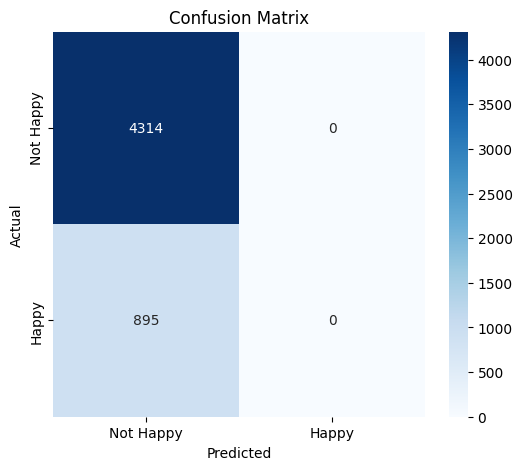

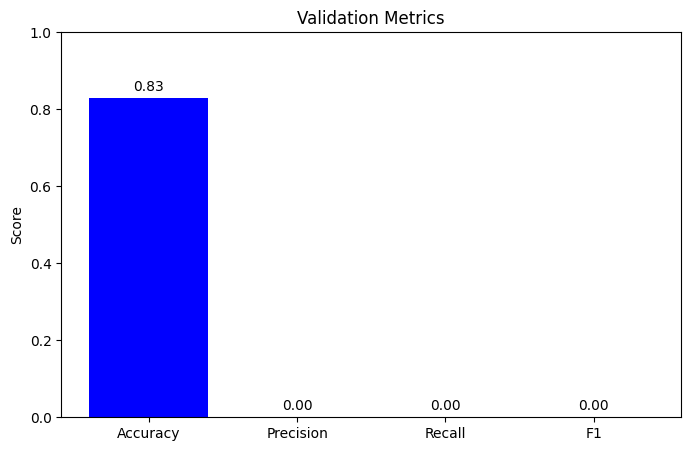

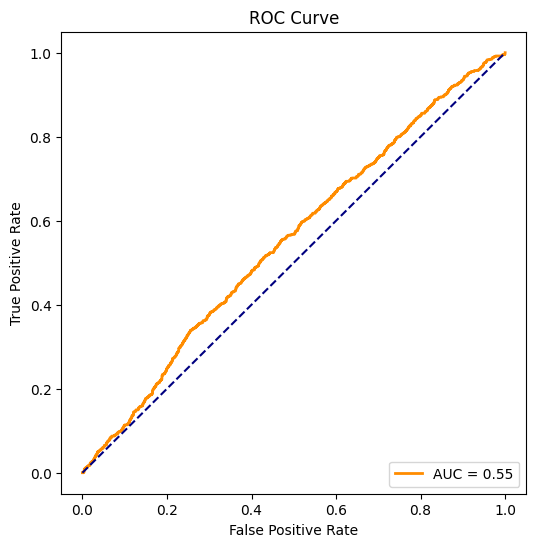

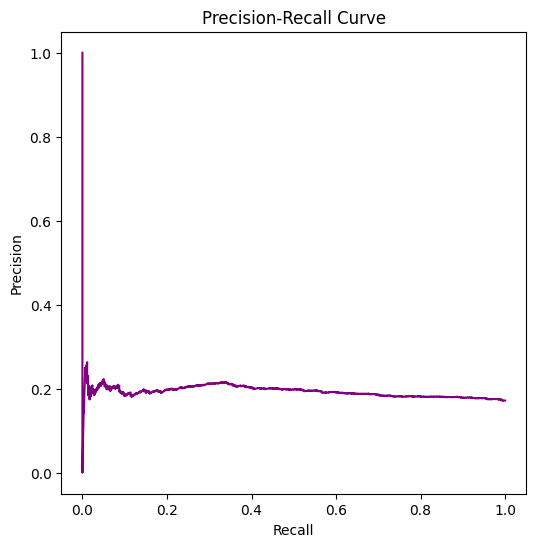


✅ Validation pipeline completed!


In [13]:
import os
import cv2
import random

import torch
import torch.nn as nn

from torch.utils.data import (
    DataLoader,
    Dataset,
    random_split
)

from torchvision import models, transforms

from PIL import Image

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)

# ============================================================
# RANDOM SEED
# ============================================================

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

# ============================================================
# CREMA-D VIDEO DATASET
# ============================================================

class CREMAVideoDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.root_dir = root_dir

        self.transform = transform

        self.video_files = [

            os.path.join(root_dir, f)

            for f in os.listdir(root_dir)

            if f.endswith(".flv")
        ]

    def __len__(self):

        return len(self.video_files)

    def __getitem__(self, idx):

        video_path = self.video_files[idx]

        filename = os.path.basename(video_path)

        # ====================================================
        # CREMA-D LABELS
        #
        # HAP = happy
        # ====================================================

        label = 1 if "_HAP_" in filename else 0

        # ====================================================
        # EXTRACT MIDDLE FRAME
        # ====================================================

        cap = cv2.VideoCapture(video_path)

        frame_count = int(
            cap.get(cv2.CAP_PROP_FRAME_COUNT)
        )

        target_frame = frame_count // 2

        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            target_frame
        )

        ret, frame = cap.read()

        cap.release()

        # fallback image
        if not ret:

            image = Image.new(
                "RGB",
                (224,224)
            )

        else:

            image = Image.fromarray(
                cv2.cvtColor(
                    frame,
                    cv2.COLOR_BGR2RGB
                )
            )

        if self.transform:

            image = self.transform(image)

        return image, label

# ============================================================
# TRANSFORMS
# ============================================================

transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# ============================================================
# FULL DATASET
# ============================================================

crema_video_dir = "/content/drive/MyDrive/VideoFlash"

full_dataset = CREMAVideoDataset(
    crema_video_dir,
    transform=transform
)

print(f"✅ Total videos: {len(full_dataset)}")

# ============================================================
# SPLIT DATASET
#
# 70% validation
# 30% testing
#
# ONLY validation set will be used now
# ============================================================

validation_size = int(
    0.7 * len(full_dataset)
)

test_size = len(full_dataset) - validation_size

validation_dataset, test_dataset = random_split(

    full_dataset,

    [validation_size, test_size]
)

print(f"✅ Validation videos: {len(validation_dataset)}")

print(f"✅ Test videos: {len(test_dataset)}")

# ============================================================
# VALIDATION LOADER
# ============================================================

validation_loader = DataLoader(

    validation_dataset,

    batch_size=32,

    shuffle=False
)

# ============================================================
# DEVICE
# ============================================================

device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"
)

print(f"✅ Using device: {device}")

# ============================================================
# LOAD TRAINED MODEL
# ============================================================

model = models.resnet18(pretrained=False)

model.fc = nn.Linear(
    model.fc.in_features,
    2
)

model.load_state_dict(

    torch.load(

        "/content/drive/MyDrive/RAVDESS_fold_1.pth",

        map_location=device
    )
)

model = model.to(device)

model.eval()

print("✅ Model loaded successfully")

# ============================================================
# LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss()

# ============================================================
# VALIDATION LOOP
# ============================================================

validation_loss = 0

all_labels = []

all_predictions = []

all_probabilities = []

with torch.no_grad():

    for images, labels in validation_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        validation_loss += loss.item()

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        happy_probabilities = probabilities[:,1]

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predicted.cpu().numpy()
        )

        all_probabilities.extend(
            happy_probabilities.cpu().numpy()
        )

# ============================================================
# METRICS
# ============================================================

avg_validation_loss = (

    validation_loss / len(validation_loader)
)

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    zero_division=0
)

cm = confusion_matrix(
    all_labels,
    all_predictions
)

# ============================================================
# RESULTS
# ============================================================

print("\n==============================")

print("📊 VALIDATION RESULTS")

print("==============================")

print(
    f"Validation Loss: "
    f"{avg_validation_loss:.4f}"
)

print(
    f"Accuracy: "
    f"{accuracy*100:.2f}%"
)

print(
    f"Precision: "
    f"{precision:.4f}"
)

print(
    f"Recall: "
    f"{recall:.4f}"
)

print(
    f"F1-Score: "
    f"{f1:.4f}"
)

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:\n")

print(

    classification_report(

        all_labels,

        all_predictions,

        target_names=[
            "Not Happy",
            "Happy"
        ]
    )
)

# ============================================================
# CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=[
        "Not Happy",
        "Happy"
    ],

    yticklabels=[
        "Not Happy",
        "Happy"
    ]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# ============================================================
# METRIC BAR PLOT
# ============================================================

metric_names = [

    "Accuracy",

    "Precision",

    "Recall",

    "F1"
]

metric_values = [

    accuracy,

    precision,

    recall,

    f1
]

plt.figure(figsize=(8,5))

bars = plt.bar(

    metric_names,

    metric_values,

    color=[
        "blue",
        "green",
        "orange",
        "red"
    ]
)

plt.ylim(0,1)

plt.title("Validation Metrics")

plt.ylabel("Score")

for bar in bars:

    height = bar.get_height()

    plt.text(

        bar.get_x() + bar.get_width()/2,

        height + 0.02,

        f"{height:.2f}",

        ha='center'
    )

plt.show()

# ============================================================
# ROC CURVE
# ============================================================

fpr, tpr, _ = roc_curve(

    all_labels,

    all_probabilities
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(6,6))

plt.plot(

    fpr,

    tpr,

    color="darkorange",

    lw=2,

    label=f"AUC = {roc_auc:.2f}"
)

plt.plot(

    [0,1],

    [0,1],

    linestyle="--",

    color="navy"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.show()

# ============================================================
# PRECISION-RECALL CURVE
# ============================================================

precision_curve, recall_curve, _ = precision_recall_curve(

    all_labels,

    all_probabilities
)

plt.figure(figsize=(6,6))

plt.plot(

    recall_curve,

    precision_curve,

    color="purple"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

print("\n✅ Validation pipeline completed!")

Testing with 30% of CREMA D

✅ Test samples: 2233


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Model loaded

🧪 TEST RESULTS
Test Loss: 0.9939
Accuracy:  82.62%
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000

Classification Report:

              precision    recall  f1-score   support

   Not Happy       0.83      1.00      0.90      1845
       Happy       0.00      0.00      0.00       388

    accuracy                           0.83      2233
   macro avg       0.41      0.50      0.45      2233
weighted avg       0.68      0.83      0.75      2233



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


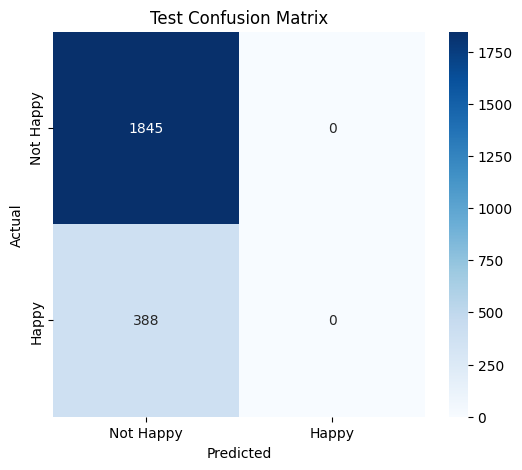

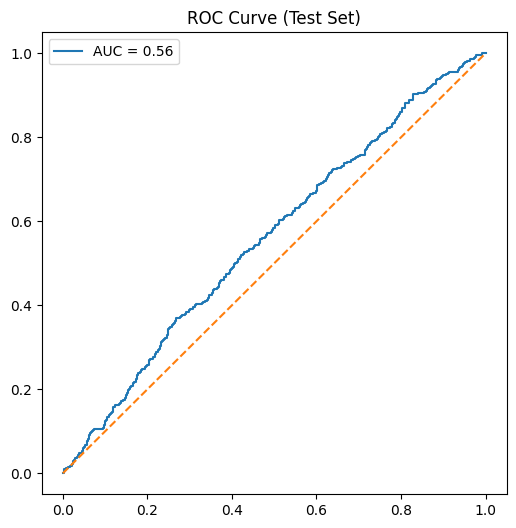

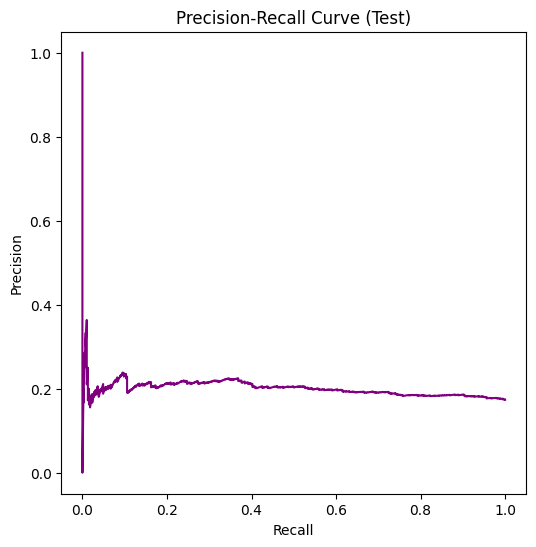


✅ Testing pipeline complete


In [14]:
import os
import cv2
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import models, transforms

from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)

# ============================================================
# DATASET
# ============================================================

class CREMAVideoDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.root_dir = root_dir
        self.transform = transform

        self.video_files = [
            os.path.join(root_dir, f)
            for f in os.listdir(root_dir)
            if f.endswith(".flv")
        ]

    def __len__(self):
        return len(self.video_files)

    def __getitem__(self, idx):

        video_path = self.video_files[idx]
        filename = os.path.basename(video_path)

        # LABELS
        label = 1 if "_HAP_" in filename else 0

        cap = cv2.VideoCapture(video_path)
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        target_frame = frame_count // 2

        cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
        ret, frame = cap.read()
        cap.release()

        if not ret:
            image = Image.new("RGB", (224, 224))
        else:
            image = Image.fromarray(
                cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            )

        if self.transform:
            image = self.transform(image)

        return image, label


# ============================================================
# TRANSFORM
# ============================================================

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# ============================================================
# DATASET SPLIT (70% validation, 30% TEST)
# ============================================================

root_dir = "/content/drive/MyDrive/VideoFlash"

full_dataset = CREMAVideoDataset(root_dir, transform=transform)

val_size = int(0.7 * len(full_dataset))
test_size = len(full_dataset) - val_size

_, test_dataset = random_split(
    full_dataset,
    [val_size, test_size]
)

print(f"✅ Test samples: {len(test_dataset)}")

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# LOAD TRAINED MODEL
# ============================================================

model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 2)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/RAVDESS_fold_1.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("✅ Model loaded")

# ============================================================
# LOSS
# ============================================================

criterion = nn.CrossEntropyLoss()

# ============================================================
# TESTING LOOP
# ============================================================

test_loss = 0

all_labels = []
all_predictions = []
all_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()

        probs = torch.softmax(outputs, dim=1)[:, 1]

        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# ============================================================
# METRICS
# ============================================================

avg_test_loss = test_loss / len(test_loader)

accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions, zero_division=0)
recall = recall_score(all_labels, all_predictions, zero_division=0)
f1 = f1_score(all_labels, all_predictions, zero_division=0)

cm = confusion_matrix(all_labels, all_predictions)

print("\n==============================")
print("🧪 TEST RESULTS")
print("==============================")

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Accuracy:  {accuracy*100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(
    all_labels,
    all_predictions,
    target_names=["Not Happy", "Happy"]
))

# ============================================================
# CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Happy", "Happy"],
            yticklabels=["Not Happy", "Happy"])
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================================
# ROC CURVE
# ============================================================

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve (Test Set)")
plt.legend()
plt.show()

# ============================================================
# PRECISION-RECALL CURVE
# ============================================================

prec, rec, _ = precision_recall_curve(all_labels, all_probs)

plt.figure(figsize=(6,6))
plt.plot(rec, prec, color="purple")
plt.title("Precision-Recall Curve (Test)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

print("\n✅ Testing pipeline complete")